# Value Function Approximation

Following various segments in Part 2 of *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [15]:
import random
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

### Gridworld

In [2]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [3]:
def get_state_features_normalized(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """Return normalized grid coords."""
    s_features = (s[0] / (grid_shape[0] - 1), s[1] / (grid_shape[1] - 1))
    return torch.Tensor(s_features)

def get_state_features_one_hot(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """
    One-hot encoding of grid state. Equivalent to tabular representation.
    """
    H, W = grid_shape
    idx = s[0] * W + s[1]

    x = torch.zeros(H * W, dtype=torch.float32)
    x[idx] = 1.0
    return x

### Linear Function Approximation

In [4]:
class Q_VFA_Linear(nn.Module):
    def __init__(self, state_dim: int, action_dim):
        super().__init__()
        self.w = nn.Linear(state_dim, action_dim, bias=False) # taking in state feature vector, spitting out Q-value for each action
    
    def forward(self, x: torch.Tensor):
        return self.w(x)

In [5]:
def pi_epsilon_greedy(s: tuple[int, int], Q_pi: Q_VFA_Linear, epsilon: float, grid_shape: tuple[int, ...]) -> int:
    p = np.random.random()

    if p < epsilon: # explore
        return int(np.random.randint(Q_pi.w.weight.shape[0]))
    return int(np.argmax(Q_pi(get_state_features_one_hot(s, grid_shape)).detach().numpy())) # exploit

In [6]:
q_hat = Q_VFA_Linear(get_state_features_one_hot(maze_env.goal_position, maze_env.grid.shape).shape[0], maze_env.action_set.__len__())
q_hat

Q_VFA_Linear(
  (w): Linear(in_features=54, out_features=4, bias=False)
)

In [7]:
q_hat.w.weight

Parameter containing:
tensor([[ 0.0652,  0.0951, -0.0141, -0.1292, -0.0216,  0.1180,  0.0814, -0.0059,
          0.0553,  0.0228,  0.0764,  0.0916,  0.0089, -0.1298, -0.0944,  0.1334,
          0.0529,  0.0971, -0.1008,  0.0517,  0.0359, -0.0590, -0.1172, -0.0705,
         -0.0760, -0.0951,  0.0858,  0.0038, -0.0155, -0.0611,  0.0497, -0.0402,
         -0.0651, -0.1179, -0.0078,  0.1108,  0.0793, -0.0601,  0.0630, -0.1214,
         -0.0847,  0.0440,  0.0078,  0.0896, -0.0889, -0.0151, -0.0185, -0.0613,
          0.1317, -0.0218, -0.0326, -0.1343,  0.0265,  0.1124],
        [ 0.0548,  0.0005,  0.1276, -0.0942,  0.0726,  0.0806,  0.1078,  0.1190,
          0.0391,  0.0220,  0.0216,  0.0039,  0.0095, -0.0071, -0.0185,  0.1319,
         -0.0525,  0.1252,  0.1018,  0.0441,  0.0699,  0.0086,  0.1306, -0.0740,
          0.0310, -0.0542,  0.0248, -0.0885, -0.0999,  0.0124, -0.0775, -0.0887,
         -0.0154, -0.0893, -0.0983,  0.0436,  0.0563,  0.0081,  0.0865,  0.0671,
          0.0633,  0.01

In [8]:
def run_SARSA_VFA(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, max_steps: int
    ) -> tuple[Q_VFA_Linear, dict]:

    q_hat = Q_VFA_Linear(get_state_features_one_hot(maze_env.goal_position, maze_env.grid.shape).shape[0], maze_env.action_set.__len__())
    grid_shape = maze_env.grid.shape
    optimizer = torch.optim.SGD(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="SARSA")
    metrics = {
        "episode_lengths": []
    }

    successes = 0
    for ep_idx in pbar:
        if ep_idx < 20:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - 20)))

        s = maze_env.reset()    

        episode_steps = 0
        for step in range(max_steps):
            phi_s = get_state_features_one_hot(s, grid_shape)

            a = pi_epsilon_greedy(s, q_hat, epsilon, grid_shape)
            r, s_prime, done = maze_env.step(a)

            # Reward adjustment for maze
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            phi_sp = get_state_features_one_hot(s_prime, grid_shape)
            a_prime = torch.argmax(q_hat(phi_sp)).item() # Greedy action (not epsilon-greedy) for stability. closer to expected SARSA/Q-learning hybrid

            prediction = q_hat(phi_s)[a]

            with torch.no_grad():
                q_next = 0.0 if done else q_hat(phi_sp)[a_prime]
                target = r + gamma * q_next
            loss = (prediction - target) ** 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            s = s_prime
            episode_steps = step + 1
            if done:
                successes += 1
                break

        metrics["episode_lengths"].append(episode_steps)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
        )
    return q_hat, metrics

In [9]:
alpha = 5e-3
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_episodes = 1000
max_steps = 150

q_hat, metrics = run_SARSA_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_episodes, max_steps)

SARSA: 100%|██████████| 1000/1000 [00:23<00:00, 42.55it/s, epsilon=0.050, steps=16, successes=826/1000] 


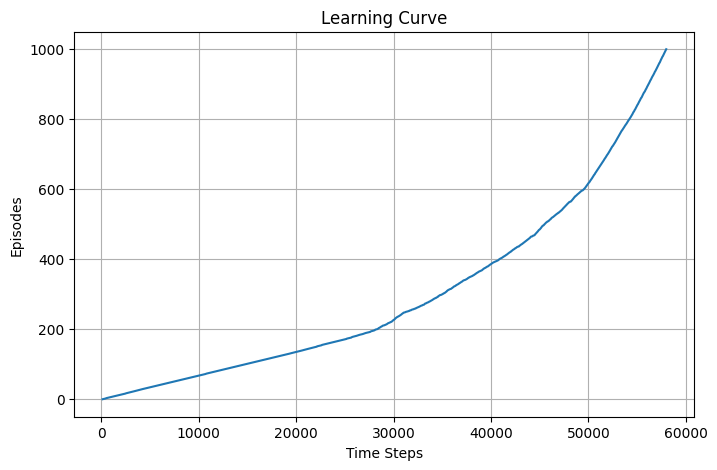

In [12]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

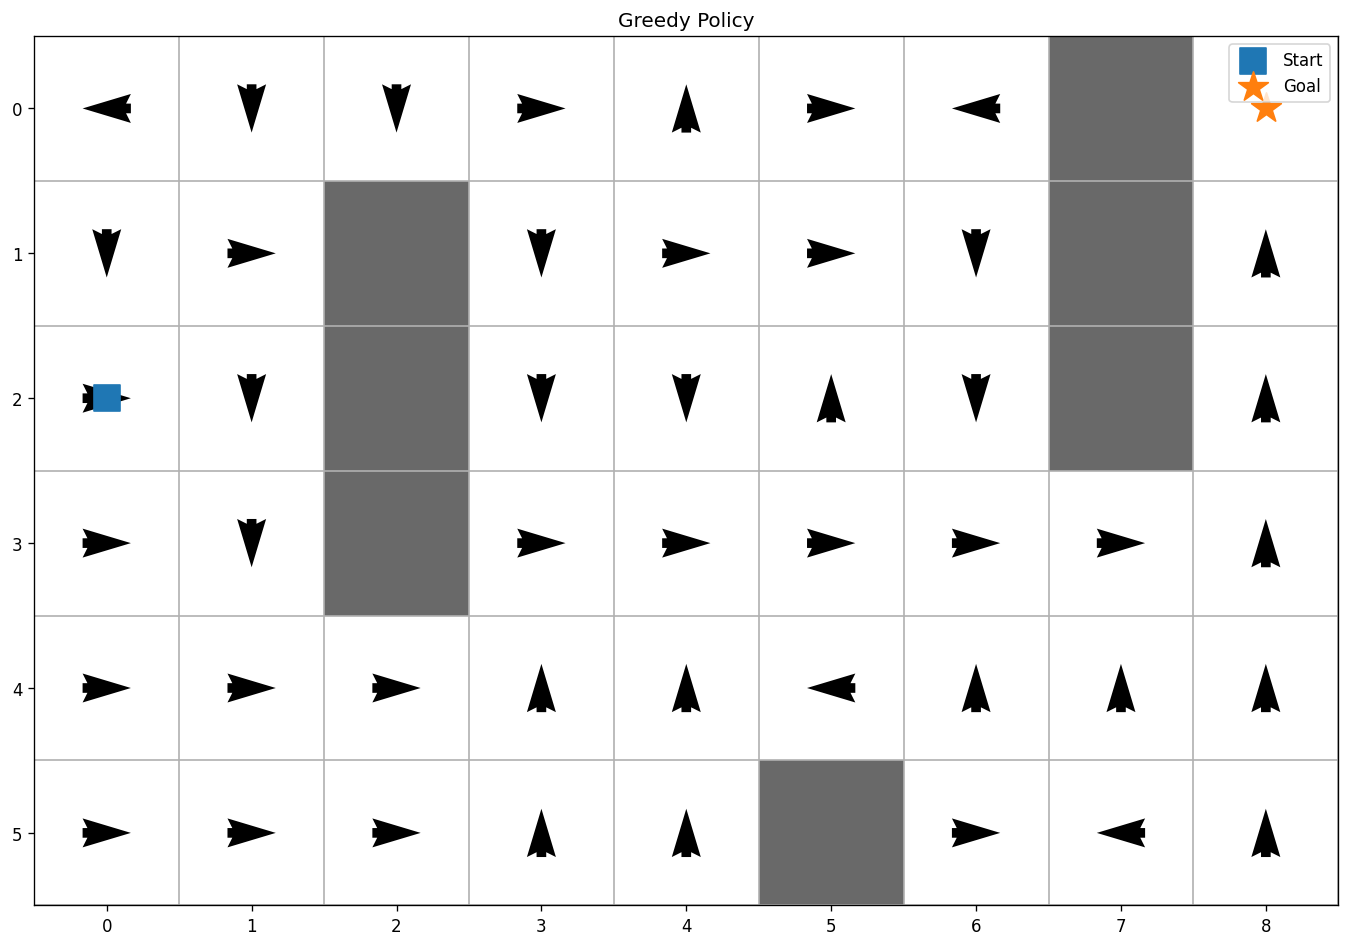

In [16]:
maze_env.plot_policy(q_hat, maze_env.action_set, get_features=partial(get_state_features_one_hot, grid_shape=maze_env.grid.shape))

In [17]:
maze_env.animate_episode_with_trail(q_hat, maze_env.action_set, get_features=partial(get_state_features_one_hot, grid_shape=maze_env.grid.shape))